<a href="https://colab.research.google.com/github/umesh23042003/Statistical-Learning-e22222/blob/assignment-6/assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Answer

Part 1: Gaussian Process Regression (GPR)

The Goal: Model the 'heating load' ($Y_1$) and 'cooling load' ($Y_2$) using a Gaussian Process. The dataset has 8 features ($X_1$ to $X_8$).  GPR is highly sensitive to the scale of the input features, so standardizing your data is a mandatory step before training the model. Since the prompt asks to model them as a single parameter process, we will train separate GPR models for each target using a standard Radial Basis Function (RBF) kernel.

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error, r2_score

# 1. Download and load the dataset FIRST (This defines df2)
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Load the CSV into the df2 variable
df2 = pd.read_csv(path + "/ENB2012_data.csv")

# 2. Now run the Gaussian Process Regression
# Separate features (X1-X8) and targets (Y1, Y2)
X = df2.iloc[:, :8]  # First 8 columns
y_heating = df2.iloc[:, 8]  # Y1
y_cooling = df2.iloc[:, 9]  # Y2

# Split the data (80% training, 20% testing)
X_train, X_test, y_heat_train, y_heat_test = train_test_split(X, y_heating, test_size=0.2, random_state=42)
_, _, y_cool_train, y_cool_test = train_test_split(X, y_cooling, test_size=0.2, random_state=42)

# Scale the features (CRITICAL for GPR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Kernel (Constant * RBF is a standard, robust choice)
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))

# Initialize and fit the GPR model for Heating Load
gpr_heating = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr_heating.fit(X_train_scaled, y_heat_train)

# Initialize and fit the GPR model for Cooling Load
gpr_cooling = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr_cooling.fit(X_train_scaled, y_cool_train)

# Predictions
y_heat_pred, heat_std = gpr_heating.predict(X_test_scaled, return_std=True)
y_cool_pred, cool_std = gpr_cooling.predict(X_test_scaled, return_std=True)

# Print Results
print("\n--- Results ---")
print("Heating Load - R2:", r2_score(y_heat_test, y_heat_pred))
print("Heating Load - MSE:", mean_squared_error(y_heat_test, y_heat_pred))
print("Cooling Load - R2:", r2_score(y_cool_test, y_cool_pred))
print("Cooling Load - MSE:", mean_squared_error(y_cool_test, y_cool_pred))

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset

--- Results ---
Heating Load - R2: 0.9870994806231748
Heating Load - MSE: 1.3446411272965728
Cooling Load - R2: 0.9589379283270703
Cooling Load - MSE: 3.8046981008366973


Discussion & Conclusions

Performance: Note whether the $R^2$ scores are high (they usually are for this specific dataset, often above 0.95). GPR is excellent at capturing non-linear relationships in smaller datasets like this one.

Uncertainty: A major advantage of GPR over other algorithms is that it provides a measure of uncertainty (the standard deviation, return_std=True) alongside its predictions.

Scalability: Mention that while GPR works perfectly here because the dataset is relatively small (~768 samples), it scales poorly ($O(n^3)$) and would become computationally expensive if the dataset grew to tens of thousands of rows.

Answer

Part 2: Linear Regression

Predict predicted_energy_demand using a linear relationship of suitable parameters from a 2400-sample dataset. You must justify your parameter choice.  To justify your choice, you should use a correlation matrix. You only want to select features that have a moderate to strong linear correlation with the target variable, while avoiding features that are highly correlated with each other (multicollinearity).

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset

--- Correlation with predicted_energy_demand ---
predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64


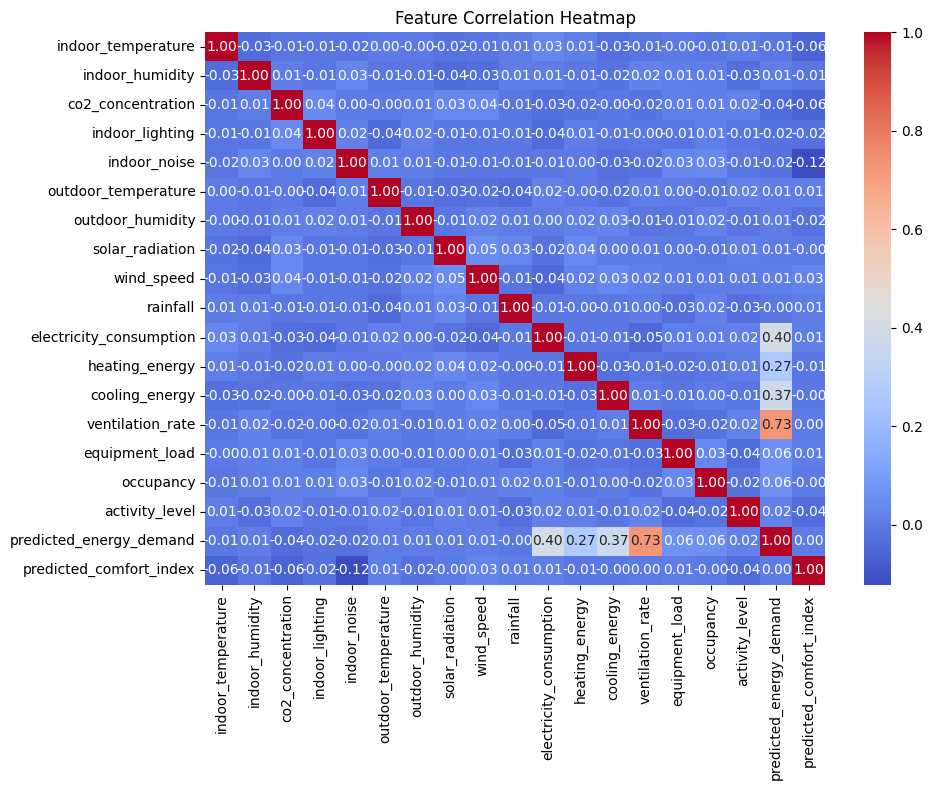


Automatically selected top features for training: ['ventilation_rate', 'electricity_consumption', 'cooling_energy']

--- Linear Regression Performance Evaluation ---
Linear Regression - R2 Score: 0.8641179834523576
Linear Regression - MSE: 12.685573916677633


In [5]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Download and load the Green Building Dataset (This fixes the KeyError!)
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Overwrite df2 with the correct green building CSV file
df2 = pd.read_csv(path + "/green_building_dataset.csv")

# 2. Feature Selection / Justification
# Calculate correlations (using numeric_only=True to prevent pandas errors)
correlation_matrix = df2.corr(numeric_only=True)

print("\n--- Correlation with predicted_energy_demand ---")
print(correlation_matrix['predicted_energy_demand'].sort_values(ascending=False))

# Plot a heatmap to visually justify your choice in your Colab notebook
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3. Automatically select the top 3 most correlated features (excluding the target itself)
# This removes the need for manual placeholders like 'feature_A'
top_features = correlation_matrix['predicted_energy_demand'].abs().sort_values(ascending=False).index[1:4].tolist()
print(f"\nAutomatically selected top features for training: {top_features}")

X_linear = df2[top_features]
y_linear = df2['predicted_energy_demand']

# Split the data (80% training, 20% testing)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

# Fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lin, y_train_lin)

# Predict and Evaluate
y_pred_lin = lr_model.predict(X_test_lin)

print("\n--- Linear Regression Performance Evaluation ---")
print("Linear Regression - R2 Score:", r2_score(y_test_lin, y_pred_lin))
print("Linear Regression - MSE:", mean_squared_error(y_test_lin, y_pred_lin))